# Notebook 08 — Test Time Augmentation (TTA)

Test Time Augmentation (TTA) applies multiple augmentations to each image at inference time and averages the resulting probability distributions. This produces more robust predictions than a single forward pass.

## What TTA does
Instead of predicting on the original image once, we predict on N augmented versions and average the probabilities:

## Notebooks structure
- **This notebook (08):** Apply TTA to `localization` and `sex_age` models, compare metrics with/without TTA, save TTA probabilities
- **Notebook 09:** Selective ensemble using TTA probabilities
- **Notebook 10:** Threshold adjustment on ensemble output

## Models
| Model | Metadata | Role |
|-------|----------|------|
| multimodal_b0_none_localization | localization | Primary |
| multimodal_b0_none_sex_age | sex + age | Secondary |

## Outputs
| File | Location | Description |
|------|----------|-------------|
| `tta_probs_localization.npy` | `outputs/metrics/` | TTA probabilities for localization model |
| `tta_probs_sex_age.npy` | `outputs/metrics/` | TTA probabilities for sex+age model |
| `tta_labels.npy` | `outputs/metrics/` | Ground truth labels (test set) |
| `tta_comparison_metrics.csv` | `outputs/metrics/` | Metrics with/without TTA |
| `tta_comparison.png` | `outputs/figures/` | Comparison plot |

In [6]:
import sys
sys.path.append('../src')

import os
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score
)
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from config import (
    METRICS_DIR, FIGURES_DIR, MODELS_DIR, OUTPUTS_DIR,
    NUM_CLASSES, BATCH_SIZE, NUM_WORKERS,
    CLASS_NAMES_FULL, IDX_TO_CLASS, CLASSES
)
from dataset import load_test_multimodal, MultimodalSkinLesionDataset
from model import MultimodalModel
from transforms import get_val_transforms

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Imports OK')

Device: cuda
Imports OK


## Setup — Models and TTA Configuration

In [7]:
MODELS = {
    'localization': {
        'metadata_cols': ['localization'],
        'label': 'localization (primary)',
    },
    'sex_age': {
        'metadata_cols': ['sex', 'age'],
        'label': 'sex + age (secondary)',
    },
}

def get_best_fold(exp_name):
    """Return the fold index with highest val AUC from record.json."""
    record_path = os.path.join(METRICS_DIR, f"{exp_name}_record.json")
    with open(record_path) as f:
        record = json.load(f)
    fold_aucs = record['results']['fold_aucs']
    return int(np.argmax(fold_aucs))

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

TTA_TRANSFORMS = [
    A.Compose([A.Resize(224, 224), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.HorizontalFlip(p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.VerticalFlip(p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.Rotate(limit=(90, 90), p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.Rotate(limit=(270, 270), p=1.0), A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
]

print(f"TTA: {len(TTA_TRANSFORMS)} augmentations per image")
print(f"Models to evaluate: {list(MODELS.keys())}")

TTA: 5 augmentations per image
Models to evaluate: ['localization', 'sex_age']


## TTA Inference

In [8]:
def run_tta_inference(model, dataset_no_transform, metadata_cols, device):
    """
    Run TTA inference on the test set.
    For each TTA transform, runs a full forward pass and averages probabilities.
    
    Args:
        model:              Trained MultimodalModel
        dataset_no_transform: Test dataset without transform (raw images)
        metadata_cols:      List of metadata columns
        device:             Torch device
    
    Returns:
        labels: Ground truth labels (N,)
        probs:  Averaged TTA probabilities (N, NUM_CLASSES)
    """
    model.eval()
    all_probs = []

    for i, transform in enumerate(TTA_TRANSFORMS):
        print(f"  TTA pass {i+1}/{len(TTA_TRANSFORMS)}...")
        
        # Apply current transform
        dataset_no_transform.transform = transform if transform is not None else get_val_transforms()
        
        loader = DataLoader(
            dataset_no_transform, batch_size=BATCH_SIZE,
            shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
        )
        
        pass_probs = []
        pass_labels = []
        
        with torch.no_grad():
            for images, metadata, labels in tqdm(loader, desc=f"Pass {i+1}", leave=False):
                images   = images.to(device)
                metadata = metadata.to(device)
                logits   = model(images, metadata)
                probs    = torch.softmax(logits, dim=1).cpu().numpy()
                pass_probs.extend(probs)
                pass_labels.extend(labels.numpy())
        
        all_probs.append(np.array(pass_probs))

    # Average probabilities across all TTA passes
    avg_probs = np.mean(all_probs, axis=0)
    return np.array(pass_labels), avg_probs


def compute_metrics(labels, probs):
    """Compute all metrics from probabilities."""
    preds = np.argmax(probs, axis=1)
    return {
        'accuracy':     accuracy_score(labels, preds),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
        'f1_macro':     f1_score(labels, preds, average='macro', zero_division=0),
        'auc_macro':    roc_auc_score(labels, probs, multi_class='ovr', average='macro'),
        'recall_mel':   recall_score(labels, preds, average=None, zero_division=0)[CLASSES.index('mel')],
        'recall_bcc':   recall_score(labels, preds, average=None, zero_division=0)[CLASSES.index('bcc')],
    }

print("TTA inference function defined OK")

TTA inference function defined OK


## Running TTA on both models

In [9]:
tta_results = {}

for exp_key, exp_config in MODELS.items():
    exp_name     = f"multimodal_b0_none_{exp_key}"
    metadata_cols = exp_config['metadata_cols']
    
    print(f"\n{'='*50}")
    print(f"Model: {exp_name}")
    print(f"{'='*50}")
    
    # Load model
    best_fold  = get_best_fold(exp_name)
    model_path = os.path.join(MODELS_DIR, f"{exp_name}_fold{best_fold}.pth")
    
    test_dataset = load_test_multimodal('none', metadata_cols, get_val_transforms())
    metadata_dim = test_dataset.get_metadata_dim()
    
    model = MultimodalModel(metadata_dim=metadata_dim, efficientnet_version='b0', pretrained=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
    model = model.to(device)
    
    # Run TTA inference
    labels, tta_probs = run_tta_inference(model, test_dataset, metadata_cols, device)
    
    # Run standard inference (no TTA) for comparison
    test_dataset.transform = get_val_transforms()
    loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    
    model.eval()
    std_probs, std_labels = [], []
    with torch.no_grad():
        for images, metadata, lbls in tqdm(loader, desc="Standard inference", leave=False):
            images   = images.to(device)
            metadata = metadata.to(device)
            logits   = model(images, metadata)
            probs    = torch.softmax(logits, dim=1).cpu().numpy()
            std_probs.extend(probs)
            std_labels.extend(lbls.numpy())
    std_probs = np.array(std_probs)
    
    # Compute metrics
    metrics_std = compute_metrics(labels, std_probs)
    metrics_tta = compute_metrics(labels, tta_probs)
    
    tta_results[exp_key] = {
        'labels':       labels,
        'std_probs':    std_probs,
        'tta_probs':    tta_probs,
        'metrics_std':  metrics_std,
        'metrics_tta':  metrics_tta,
    }
    
    print(f"\n  {'Metric':<15} {'Standard':>10} {'TTA':>10} {'Δ':>10}")
    print(f"  {'-'*45}")
    for metric in ['auc_macro', 'recall_macro', 'recall_mel', 'recall_bcc', 'f1_macro']:
        std_val = metrics_std[metric]
        tta_val = metrics_tta[metric]
        delta   = tta_val - std_val
        arrow   = '↑' if delta > 0 else '↓'
        print(f"  {metric:<15} {std_val:>10.4f} {tta_val:>10.4f} {arrow}{abs(delta):>8.4f}")
    
    # Free GPU memory
    model.cpu()
    del model
    torch.cuda.empty_cache()

print("\nTTA inference complete!")


Model: multimodal_b0_none_localization
  TTA pass 1/5...


Pass 1:   0%|          | 0/47 [00:00<?, ?it/s]

  TTA pass 2/5...


  TTA pass 3/5...


  TTA pass 4/5...


...

  TTA pass 2/5...


  TTA pass 3/5...


  TTA pass 4/5...


  TTA pass 5/5...



  Metric            Standard        TTA          Δ
  ---------------------------------------------
  auc_macro           0.9616     0.9668 ↑  0.0052
  recall_macro        0.7493     0.7473 ↓  0.0020
  recall_mel          0.6964     0.7024 ↑  0.0060
  recall_bcc          0.8442     0.8182 ↓  0.0260
  f1_macro            0.7033     0.7047 ↑  0.0014

TTA inference complete!


## Comparison — Standard vs TTA

In [10]:
rows = []
for exp_key, data in tta_results.items():
    for mode, metrics in [('Standard', data['metrics_std']), ('TTA', data['metrics_tta'])]:
        rows.append({
            'Model':        exp_key,
            'Mode':         mode,
            'AUC macro':    round(metrics['auc_macro'], 4),
            'Recall macro': round(metrics['recall_macro'], 4),
            'Recall mel':   round(metrics['recall_mel'], 4),
            'Recall bcc':   round(metrics['recall_bcc'], 4),
            'F1 macro':     round(metrics['f1_macro'], 4),
        })

df_tta = pd.DataFrame(rows)
print(df_tta.to_string(index=False))

       Model     Mode  AUC macro  Recall macro  Recall mel  Recall bcc  F1 macro
localization Standard     0.9613        0.7187      0.7976      0.7662    0.6871
localization      TTA     0.9656        0.7093      0.7798      0.7792    0.6908
     sex_age Standard     0.9616        0.7493      0.6964      0.8442    0.7033
     sex_age      TTA     0.9668        0.7473      0.7024      0.8182    0.7047


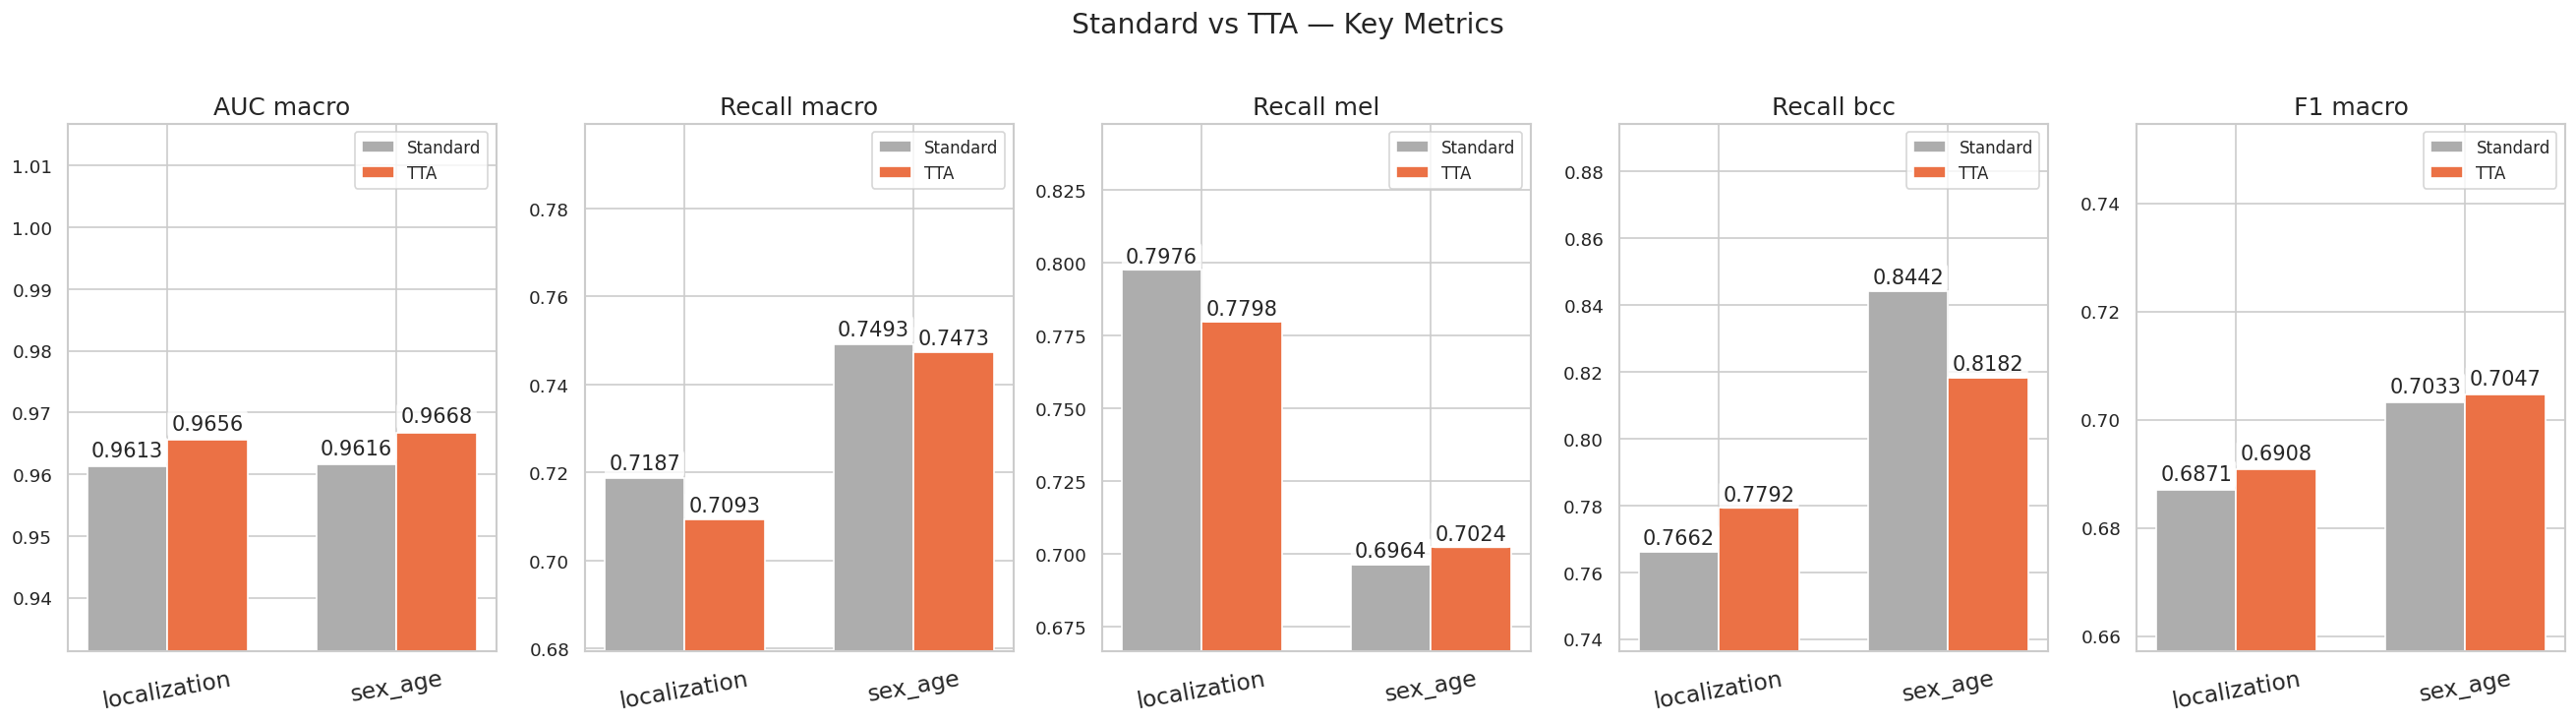

Saved: tta_comparison.png


In [22]:
metrics_to_plot = ['AUC macro', 'Recall macro', 'Recall mel', 'Recall bcc', 'F1 macro']
models          = list(tta_results.keys())

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 6))

for ax, metric in zip(axes, metrics_to_plot):
    x     = np.arange(len(models))
    width = 0.35

    std_vals = [tta_results[m]['metrics_std'][metric.lower().replace(' ', '_')] for m in models]
    tta_vals = [tta_results[m]['metrics_tta'][metric.lower().replace(' ', '_')] for m in models]

    bars1 = ax.bar(x - width/2, std_vals, width, label='Standard', color="#ADADAD", edgecolor='white')
    bars2 = ax.bar(x + width/2, tta_vals, width, label='TTA',      color="#EB7145", edgecolor='white')

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                    f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=12.5,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14, rotation=10)
    ax.set_title(metric, fontsize=15)
    ax.set_ylim(min(std_vals + tta_vals) - 0.03, max(std_vals + tta_vals) + 0.05)
    ax.legend(fontsize=10)

plt.suptitle('Standard vs TTA — Key Metrics', fontsize=17, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tta_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tta_comparison.png")

## Saving Probabilities

To avoid reloading models in subsequent notebooks, probabilities are saved to `outputs/metrics/`:

**Standard probabilities** (no TTA) → saved in **Notebook 07** (evaluation notebook)
| File | Description |
|------|-------------|
| `std_probs_localization.npy` | Standard probabilities — localization model |
| `std_probs_sex_age.npy` | Standard probabilities — sex_age model |
| `std_labels.npy` | Ground truth labels (test set) |

**TTA probabilities** → saved here
| File | Description |
|------|-------------|
| `tta_probs_localization.npy` | TTA probabilities — localization model |
| `tta_probs_sex_age.npy` | TTA probabilities — sex_age model |

Both sets of probabilities will be used in **Notebook 09 (Selective Ensemble)** to compare the 4 combinations:
1. Standard + threshold 0.5
2. TTA + threshold 0.5
3. Standard + threshold adjustment
4. TTA + threshold adjustment

In [24]:
for exp_key, data in tta_results.items():
    np.save(os.path.join(METRICS_DIR, f'tta_probs_{exp_key}.npy'), data['tta_probs'])

print("Saved TTA probabilities:")
for exp_key in tta_results.keys():
    print(f"    tta_probs_{exp_key}.npy → {METRICS_DIR}")

Saved TTA probabilities:
    tta_probs_localization.npy → /home/maialen/skin_lesion_PFG/outputs/metrics
    tta_probs_sex_age.npy → /home/maialen/skin_lesion_PFG/outputs/metrics


---
## Conclusions

### TTA improves AUC and F1 consistently
Both models show a consistent improvement in AUC macro (~+0.005) and F1 macro (~+0.002) with TTA.

### TTA has mixed effects on recall
- **localization:** Recall melanoma ↓ -0.018 — concerning for our primary clinical metric
- **sex_age:** Recall melanoma ↑ +0.006 — small improvement

### TTA alone is not sufficient
At default threshold 0.5, TTA does not provide a net improvement for our clinical objective (recall melanoma). However, TTA produces better calibrated probabilities which are expected to benefit **threshold adjustment** in Notebook 10.

### Decision
TTA and standard probabilities are both carried forward to Notebook 09. The final decision on whether to use TTA is made after threshold adjustment in Notebook 10, where all 4 combinations are compared:
1. Standard + threshold 0.5
2. TTA + threshold 0.5  
3. Standard + threshold adjustment
4. **TTA + threshold adjustment** ← expected best

### Next step
→ **Notebook 07** — add cells to save standard probabilities
→ **Notebook 09** — Selective Ensemble